In [1]:
import pandas as pd

signalp = pd.read_csv(
    r"N:\Jupiter_Projects\enzyme-genome-mining-course\results\signalp/prediction_results.txt",
    sep="\t",
    skiprows=1
)

signalp

,# ID,Prediction,OTHER,SP(Sec/SPI),CS Position
0,sp|G0R6T8|LP9A_HYPJQ AA9 family lytic polysacc...,SP,0.000151,0.999866,CS pos: 21-22. Pr: 0.9838
1,tr|G0RAB4|G0RAB4_HYPJQ Histone acetyltransfera...,OTHER,1.000000,0.000000,NaN
2,tr|G0RAV5|G0RAV5_HYPJQ Ubiquitin-conjugating e...,OTHER,1.000000,0.000000,NaN
3,sp|G0RBE3|IRE1_HYPJQ Serine/threonine-protein ...,SP,0.000187,0.999812,CS pos: 35-36. Pr: 0.9752
4,tr|G0RBU9|G0RBU9_HYPJQ Adenylyltransferase and...,OTHER,1.000000,0.000000,NaN
...,...,...,...,...,...
9110,tr|G0RXQ4|G0RXQ4_HYPJQ Predicted protein (Frag...,OTHER,0.999987,0.000000,NaN
9111,tr|G0RXQ5|G0RXQ5_HYPJQ Predicted protein (Frag...,OTHER,0.881777,0.118205,NaN
9112,tr|G0RXQ6|G0RXQ6_HYPJQ Predicted protein OS=Hy...,OTHER,1.000000,0.000000,NaN
9113,tr|G0RXQ7|G0RXQ7_HYPJQ Predicted protein (Frag...,OTHER,1.000000,0.000000,NaN


In [2]:
signalp.columns

Index(['# ID', 'Prediction', 'OTHER', 'SP(Sec/SPI)', 'CS Position'], dtype='str')

In [3]:
secreted = signalp[signalp["Prediction"] == "SP"]

In [4]:
secreted["protein_id"] = secreted["# ID"].str.split("|").str[1]

In [5]:
secreted_ids = set(secreted["protein_id"])
secreted_ids

{'G0R6Q5',
 'G0R6S3',
 'G0R6S4',
 'G0R6S5',
 'G0R6T3',
 'G0R6T5',
 'G0R6T6',
 'G0R6T7',
 'G0R6T8',
 'G0R6V4',
 'G0R6W9',
 'G0R6X8',
 'G0R713',
 'G0R719',
 'G0R720',
 'G0R741',
 'G0R756',
 'G0R771',
 'G0R773',
 'G0R789',
 'G0R7M8',
 'G0R7N5',
 'G0R7Q4',
 'G0R7T9',
 'G0R7V3',
 'G0R7V8',
 'G0R7W4',
 'G0R816',
 'G0R830',
 'G0R851',
 'G0R853',
 'G0R863',
 'G0R866',
 'G0R8D1',
 'G0R8D5',
 'G0R8E3',
 'G0R8E8',
 'G0R8F9',
 'G0R8G1',
 'G0R8G2',
 'G0R8L9',
 'G0R8N5',
 'G0R8N9',
 'G0R8P0',
 'G0R8P9',
 'G0R8Q3',
 'G0R8R1',
 'G0R8S9',
 'G0R8T0',
 'G0R8V4',
 'G0R900',
 'G0R906',
 'G0R911',
 'G0R915',
 'G0R916',
 'G0R927',
 'G0R931',
 'G0R938',
 'G0R947',
 'G0R949',
 'G0R950',
 'G0R989',
 'G0R990',
 'G0R994',
 'G0R9D1',
 'G0R9G0',
 'G0R9I4',
 'G0R9I9',
 'G0R9J0',
 'G0R9J4',
 'G0R9J5',
 'G0R9K1',
 'G0R9K4',
 'G0R9K5',
 'G0R9L5',
 'G0R9S6',
 'G0R9W5',
 'G0R9X1',
 'G0R9X3',
 'G0RA00',
 'G0RA02',
 'G0RA06',
 'G0RA10',
 'G0RA27',
 'G0RA29',
 'G0RA32',
 'G0RA39',
 'G0RA48',
 'G0RA57',
 'G0RA70',
 'G0RA73',

In [6]:
from Bio import SeqIO

records = []

for record in SeqIO.parse("N:\Jupiter_Projects\enzyme-genome-mining-course\data/proteomes/trichoderma_reesei_QM6a.fasta", "fasta"):
    if record.id.split("|")[1] in secreted_ids:
        records.append(record)

SeqIO.write(records, r"N:\Jupiter_Projects\enzyme-genome-mining-course\results/secretome.fasta", "fasta")

679

In [7]:
secreted["SP(Sec/SPI)"].describe()

count    679.000000
mean       0.980343
std        0.073999
min        0.500640
25%        0.999788
50%        0.999819
75%        0.999839
max        1.000000
Name: SP(Sec/SPI), dtype: float64

In [8]:
secreted.sort_values("SP(Sec/SPI)").head(10)

,# ID,Prediction,OTHER,SP(Sec/SPI),CS Position,protein_id
7025,tr|G0RPC6|G0RPC6_HYPJQ Predicted protein OS=Hy...,SP,0.499353,0.500640,CS pos: 22-23. Pr: 0.2923,G0RPC6
7525,tr|G0RRF8|G0RRF8_HYPJQ Glycosyltransferase fam...,SP,0.495197,0.504820,CS pos: 29-30. Pr: 0.4771,G0RRF8
4577,tr|G0RE98|G0RE98_HYPJQ Predicted protein (Frag...,SP,0.479008,0.521009,CS pos: 4-5. Pr: 0.4360,G0RE98
5341,tr|G0RHD0|G0RHD0_HYPJQ Predicted protein OS=Hy...,SP,0.451270,0.548781,CS pos: 24-25. Pr: 0.4661,G0RHD0
7495,tr|G0RRB4|G0RRB4_HYPJQ Predicted protein (Frag...,SP,0.412819,0.587183,CS pos: 33-34. Pr: 0.4236,G0RRB4
8316,tr|G0RUL5|G0RUL5_HYPJQ Predicted protein OS=Hy...,SP,0.392560,0.607462,CS pos: 30-31. Pr: 0.3917,G0RUL5
8702,tr|G0RW53|G0RW53_HYPJQ Predicted protein OS=Hy...,SP,0.386736,0.613280,CS pos: 30-31. Pr: 0.5453,G0RW53
4454,tr|G0RDR8|G0RDR8_HYPJQ Predicted protein OS=Hy...,SP,0.381582,0.618416,CS pos: 26-27. Pr: 0.6511,G0RDR8
4091,tr|G0RC42|G0RC42_HYPJQ Predicted protein OS=Hy...,SP,0.341091,0.658871,CS pos: 50-51. Pr: 0.5582,G0RC42
1373,tr|G0RG39|G0RG39_HYPJQ Fungal specific transcr...,SP,0.335800,0.664210,CS pos: 11-12. Pr: 0.6563,G0RG39


In [9]:
# % of sercreted proteins:
len(secreted)/len(signalp)*100

7.449259462424575

In [10]:
len(signalp)

9115

In [11]:
import pandas as pd
import sys
from Bio import SeqIO
from pathlib import Path

#fasta_file = sys.argv[1]
fasta_file = "../data/proteomes/trichoderma_reesei_QM6a.fasta"

lengths = []
ids = []

for record in SeqIO.parse(fasta_file, "fasta"):
    ids.append(record.id)
    lengths.append(len(record.seq))

df = pd.DataFrame({
    "protein_id": ids,
    "length": lengths
})

In [12]:
#length distribution of secreted proteins
secreted["length"] = (
    secreted["protein_id"]
    .map(df.set_index(df["protein_id"].str.split("|").str[1])["length"])
)

#secreted["length"] = secreted["protein_id"].map(df.set_index("protein_id")["length"])
secreted["length"].describe()

count     679.000000
mean      432.198822
std       270.539487
min        65.000000
25%       239.000000
50%       394.000000
75%       550.000000
max      2770.000000
Name: length, dtype: float64

In [18]:
secreted.sort_values('length', ascending = False).head(20)

,# ID,Prediction,OTHER,SP(Sec/SPI),CS Position,protein_id,length
8177,tr|G0RU23|G0RU23_HYPJQ Predicted protein OS=Hy...,SP,0.000178,0.999819,CS pos: 29-30. Pr: 0.9813,G0RU23,2770
4834,tr|G0RFA4|G0RFA4_HYPJQ Predicted protein OS=Hy...,SP,0.000171,0.999846,CS pos: 30-31. Pr: 0.4970,G0RFA4,1626
436,tr|G0RT37|G0RT37_HYPJQ chitinase OS=Hypocrea j...,SP,0.000159,0.999857,CS pos: 29-30. Pr: 0.5616,G0RT37,1531
7017,tr|G0RPB5|G0RPB5_HYPJQ Predicted protein OS=Hy...,SP,0.000176,0.999843,CS pos: 17-18. Pr: 0.9834,G0RPB5,1515
160,tr|G0RCD8|G0RCD8_HYPJQ Vacuolar protein sortin...,SP,0.000194,0.999804,CS pos: 27-28. Pr: 0.9787,G0RCD8,1508
1778,tr|G0RKH0|G0RKH0_HYPJQ Glycosyltransferase fam...,SP,0.000152,0.999857,CS pos: 23-24. Pr: 0.9850,G0RKH0,1487
452,tr|G0RTY5|G0RTY5_HYPJQ tripeptidyl-peptidase I...,SP,0.000000,1.000000,CS pos: 19-20. Pr: 0.9976,G0RTY5,1419
505,tr|G0R6S5|G0R6S5_HYPJQ chitinase OS=Hypocrea j...,SP,0.000201,0.999776,CS pos: 25-26. Pr: 0.9734,G0R6S5,1377
946,tr|G0RBC0|G0RBC0_HYPJQ Predicted protein OS=Hy...,SP,0.000203,0.999808,CS pos: 21-22. Pr: 0.8473,G0RBC0,1272
3,sp|G0RBE3|IRE1_HYPJQ Serine/threonine-protein ...,SP,0.000187,0.999812,CS pos: 35-36. Pr: 0.9752,G0RBE3,1243


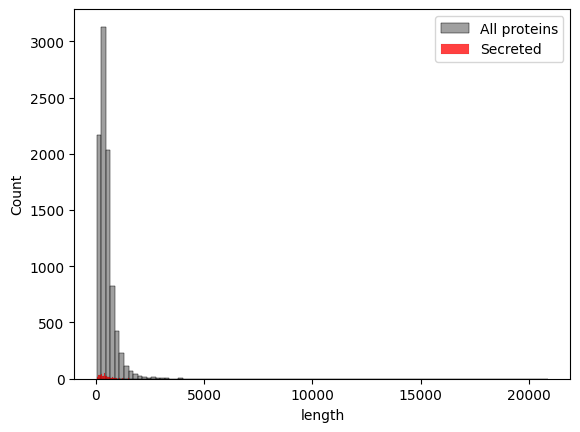

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.histplot(df["length"], bins=100, color="gray", label="All proteins")
sns.histplot(secreted["length"], bins=100, color="red", label="Secreted")


plt.legend()

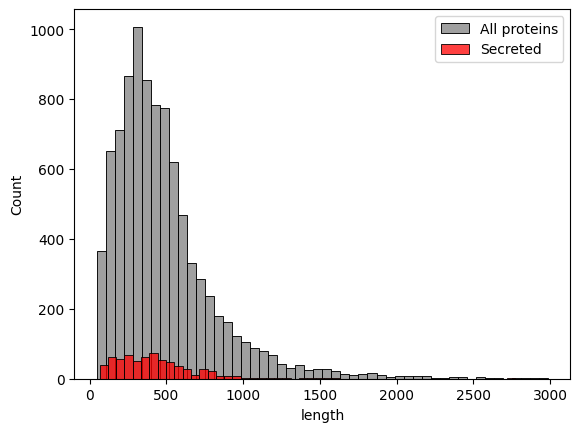

In [176]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.histplot(df[df["length"] < 3000]["length"], bins=50, color="gray", label="All proteins")
sns.histplot(secreted[secreted["length"] < 3000]["length"], bins=50, color="red", label="Secreted")

plt.legend()
plt.savefig("N:\Jupiter_Projects\enzyme-genome-mining-course/results/sectretome_dist.png")


In [35]:
(secreted["length"] < 300).sum()

np.int64(239)

In [36]:
secreted.to_csv("../results/secretome_predictions.csv", index=False)

In [45]:
slow = pd.read_csv("../results/signalp/prediction_results.txt", sep="\t", skiprows=1)
fast = pd.read_csv("../results/signalpf/prediction_results.txt", sep="\t", skiprows=1)


,# ID,Prediction,OTHER,SP(Sec/SPI),CS Position
0,sp|G0R6T8|LP9A_HYPJQ AA9 family lytic polysacc...,SP,0.000151,0.999866,CS pos: 21-22. Pr: 0.9838
1,tr|G0RAB4|G0RAB4_HYPJQ Histone acetyltransfera...,OTHER,1.000000,0.000000,NaN
2,tr|G0RAV5|G0RAV5_HYPJQ Ubiquitin-conjugating e...,OTHER,1.000000,0.000000,NaN
3,sp|G0RBE3|IRE1_HYPJQ Serine/threonine-protein ...,SP,0.000187,0.999812,CS pos: 35-36. Pr: 0.9752
4,tr|G0RBU9|G0RBU9_HYPJQ Adenylyltransferase and...,OTHER,1.000000,0.000000,NaN
...,...,...,...,...,...
9110,tr|G0RXQ4|G0RXQ4_HYPJQ Predicted protein (Frag...,OTHER,0.999987,0.000000,NaN
9111,tr|G0RXQ5|G0RXQ5_HYPJQ Predicted protein (Frag...,OTHER,0.881777,0.118205,NaN
9112,tr|G0RXQ6|G0RXQ6_HYPJQ Predicted protein OS=Hy...,OTHER,1.000000,0.000000,NaN
9113,tr|G0RXQ7|G0RXQ7_HYPJQ Predicted protein (Frag...,OTHER,1.000000,0.000000,NaN


In [51]:
slow["id"] = slow["# ID"].str.split("|").str[1]
fast["id"] = fast["# ID"].str.split("|").str[1]

In [52]:
#Disagreement count between Slow and Fast models
cmp = slow[["id","Prediction","SP(Sec/SPI)"]].merge(
    fast[["id","Prediction"]],
    on="id",
    suffixes=("_slow","_fast")
)
(cmp["Prediction_slow"] != cmp["Prediction_fast"]).sum()

np.int64(61)

In [53]:
cmp

,id,Prediction_slow,SP(Sec/SPI),Prediction_fast
0,G0R6T8,SP,0.999866,SP
1,G0RAB4,OTHER,0.000000,OTHER
2,G0RAV5,OTHER,0.000000,OTHER
3,G0RBE3,SP,0.999812,SP
4,G0RBU9,OTHER,0.000000,OTHER
...,...,...,...,...
9110,G0RXQ4,OTHER,0.000000,OTHER
9111,G0RXQ5,OTHER,0.118205,OTHER
9112,G0RXQ6,OTHER,0.000000,OTHER
9113,G0RXQ7,OTHER,0.000000,OTHER


In [107]:
dis = cmp[cmp["Prediction_slow"] != cmp["Prediction_fast"]]
print(len(dis))
print(dis)

61
          id Prediction_slow  SP(Sec/SPI) Prediction_fast
76    G0R755           OTHER     0.369875              SP
507   G0R6T6              SP     0.999830           OTHER
864   G0RAH4           OTHER     0.166642              SP
1134  G0RDC0              SP     0.666462           OTHER
1386  G0RGA2           OTHER     0.499848              SP
...      ...             ...          ...             ...
8565  G0RVM4              SP     0.999610           OTHER
8598  G0RVR5           OTHER     0.000000              SP
8702  G0RW53              SP     0.613280           OTHER
8713  G0RW65              SP     0.999814           OTHER
9087  G0RXM8           OTHER     0.402448              SP

[61 rows x 4 columns]


In [108]:
dis.sort_values("SP(Sec/SPI)")

,id,Prediction_slow,SP(Sec/SPI),Prediction_fast
2171,G0RQ17,OTHER,0.000000,SP
3867,G0RB70,OTHER,0.000000,SP
5365,G0RHG0,OTHER,0.000000,SP
6046,G0RKB2,OTHER,0.000000,SP
8598,G0RVR5,OTHER,0.000000,SP
...,...,...,...,...
8713,G0RW65,SP,0.999814,OTHER
1968,G0RML6,SP,0.999816,OTHER
507,G0R6T6,SP,0.999830,OTHER
2293,G0RRB3,SP,0.999853,OTHER


In [109]:
dis["SP(Sec/SPI)"].describe()

count    61.000000
mean      0.589434
std       0.336089
min       0.000000
25%       0.338452
50%       0.658871
75%       0.998460
max       0.999860
Name: SP(Sec/SPI), dtype: float64

<Axes: xlabel='SP(Sec/SPI)', ylabel='Count'>

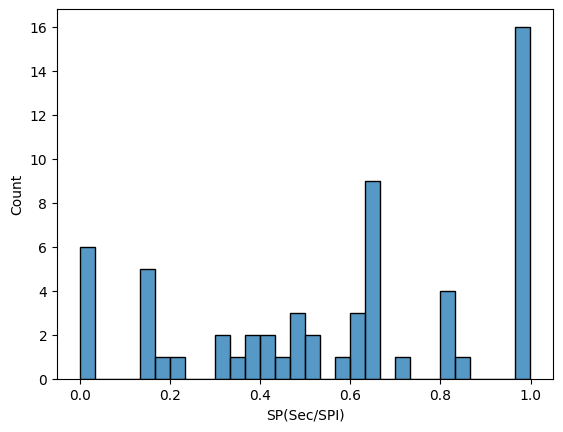

In [110]:
#disagreement distribution
sns.histplot(dis["SP(Sec/SPI)"], bins=30)

In [111]:
slow_sp = (slow["Prediction"] == "SP").sum()
fast_sp = (fast["Prediction"] == "SP").sum()

slow_sp, fast_sp

(np.int64(679), np.int64(666))

In [112]:
dis.columns

Index(['id', 'Prediction_slow', 'SP(Sec/SPI)', 'Prediction_fast'], dtype='str')

In [113]:
df.columns

Index(['protein_id', 'length', 'uid', 'id'], dtype='str')

In [114]:
df_ids

,protein_id,length,uid
0,sp|G0R6T8|LP9A_HYPJQ,344,G0R6T8
1,tr|G0RAB4|G0RAB4_HYPJQ,502,G0RAB4
2,tr|G0RAV5|G0RAV5_HYPJQ,151,G0RAV5
3,sp|G0RBE3|IRE1_HYPJQ,1243,G0RBE3
4,tr|G0RBU9|G0RBU9_HYPJQ,484,G0RBU9
...,...,...,...
9110,tr|G0RXQ4|G0RXQ4_HYPJQ,50,G0RXQ4
9111,tr|G0RXQ5|G0RXQ5_HYPJQ,138,G0RXQ5
9112,tr|G0RXQ6|G0RXQ6_HYPJQ,561,G0RXQ6
9113,tr|G0RXQ7|G0RXQ7_HYPJQ,531,G0RXQ7


In [115]:
df["uid"] = df["protein_id"].str.split("|").str[1]

dis = dis.merge(df[["uid","length"]], left_on="id", right_on="uid")

dis["length"].describe()

count      61.000000
mean      438.983607
std       246.827031
min        77.000000
25%       256.000000
50%       410.000000
75%       556.000000
max      1228.000000
Name: length, dtype: float64

In [145]:
dfdis

,protein_id,length
0,sp|G0R6T8|LP9A_HYPJQ,344
1,tr|G0RAB4|G0RAB4_HYPJQ,502
2,tr|G0RAV5|G0RAV5_HYPJQ,151
3,sp|G0RBE3|IRE1_HYPJQ,1243
4,tr|G0RBU9|G0RBU9_HYPJQ,484
...,...,...
9110,tr|G0RXQ4|G0RXQ4_HYPJQ,50
9111,tr|G0RXQ5|G0RXQ5_HYPJQ,138
9112,tr|G0RXQ6|G0RXQ6_HYPJQ,561
9113,tr|G0RXQ7|G0RXQ7_HYPJQ,531


Text(0, 0.5, 'Fast model predicts SP')

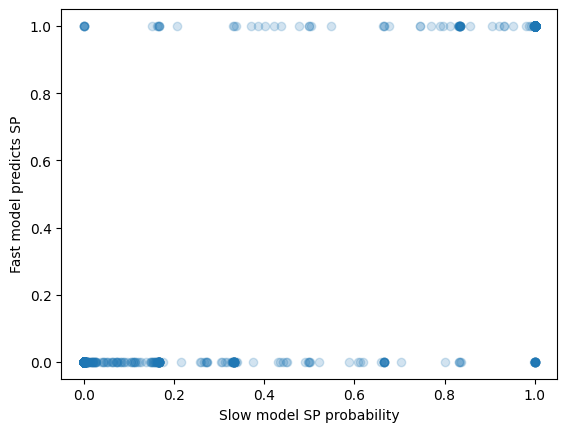

In [117]:
import matplotlib.pyplot as plt

plt.scatter(cmp["SP(Sec/SPI)"], cmp["Prediction_fast"]=="SP", alpha=0.2)
plt.xlabel("Slow model SP probability")
plt.ylabel("Fast model predicts SP")

In [118]:
dis = dis.merge(
    slow[["id", "CS Position"]],
    on="id",
    how="left"
)

In [131]:
print(dis["CS Position"].dropna().tolist())

['CS pos: 20-21. Pr: 0.9938', 'CS pos: 16-17. Pr: 0.6311', 'CS pos: 26-27. Pr: 0.9820', 'CS pos: 18-19. Pr: 0.9834', 'CS pos: 20-21. Pr: 0.6444', 'CS pos: 22-23. Pr: 0.7871', 'CS pos: 23-24. Pr: 0.4658', 'CS pos: 3-4. Pr: 0.2818', 'CS pos: 18-19. Pr: 0.9628', 'CS pos: 18-19. Pr: 0.7964', 'CS pos: 50-51. Pr: 0.5582', 'CS pos: 19-20. Pr: 0.9844', 'CS pos: 26-27. Pr: 0.6511', 'CS pos: 34-35. Pr: 0.8095', 'CS pos: 4-5. Pr: 0.4360', 'CS pos: 37-38. Pr: 0.9735', 'CS pos: 24-25. Pr: 0.7855', 'CS pos: 21-22. Pr: 0.9480', 'CS pos: 25-26. Pr: 0.8148', 'CS pos: 27-28. Pr: 0.6153', 'CS pos: 16-17. Pr: 0.9859', 'CS pos: 20-21. Pr: 0.9838', 'CS pos: 22-23. Pr: 0.2923', 'CS pos: 17-18. Pr: 0.9908', 'CS pos: 33-34. Pr: 0.4236', 'CS pos: 11-12. Pr: 0.7471', 'CS pos: 7-8. Pr: 0.6196', 'CS pos: 8-9. Pr: 0.5904', 'CS pos: 18-19. Pr: 0.4979', 'CS pos: 10-11. Pr: 0.9537', 'CS pos: 19-20. Pr: 0.9824', 'CS pos: 30-31. Pr: 0.3917', 'CS pos: 10-11. Pr: 0.9336', 'CS pos: 20-21. Pr: 0.6449', 'CS pos: 29-30. Pr: 0

In [156]:
df["id"] = df["protein_id"].str.split("|").str[1]
df

,protein_id,length,id
0,sp|G0R6T8|LP9A_HYPJQ,344,G0R6T8
1,tr|G0RAB4|G0RAB4_HYPJQ,502,G0RAB4
2,tr|G0RAV5|G0RAV5_HYPJQ,151,G0RAV5
3,sp|G0RBE3|IRE1_HYPJQ,1243,G0RBE3
4,tr|G0RBU9|G0RBU9_HYPJQ,484,G0RBU9
...,...,...,...
9110,tr|G0RXQ4|G0RXQ4_HYPJQ,50,G0RXQ4
9111,tr|G0RXQ5|G0RXQ5_HYPJQ,138,G0RXQ5
9112,tr|G0RXQ6|G0RXQ6_HYPJQ,561,G0RXQ6
9113,tr|G0RXQ7|G0RXQ7_HYPJQ,531,G0RXQ7


In [100]:
slow

,# ID,Prediction,OTHER,SP(Sec/SPI),CS Position,id
0,sp|G0R6T8|LP9A_HYPJQ AA9 family lytic polysacc...,SP,0.000151,0.999866,CS pos: 21-22. Pr: 0.9838,G0R6T8
1,tr|G0RAB4|G0RAB4_HYPJQ Histone acetyltransfera...,OTHER,1.000000,0.000000,NaN,G0RAB4
2,tr|G0RAV5|G0RAV5_HYPJQ Ubiquitin-conjugating e...,OTHER,1.000000,0.000000,NaN,G0RAV5
3,sp|G0RBE3|IRE1_HYPJQ Serine/threonine-protein ...,SP,0.000187,0.999812,CS pos: 35-36. Pr: 0.9752,G0RBE3
4,tr|G0RBU9|G0RBU9_HYPJQ Adenylyltransferase and...,OTHER,1.000000,0.000000,NaN,G0RBU9
...,...,...,...,...,...,...
9110,tr|G0RXQ4|G0RXQ4_HYPJQ Predicted protein (Frag...,OTHER,0.999987,0.000000,NaN,G0RXQ4
9111,tr|G0RXQ5|G0RXQ5_HYPJQ Predicted protein (Frag...,OTHER,0.881777,0.118205,NaN,G0RXQ5
9112,tr|G0RXQ6|G0RXQ6_HYPJQ Predicted protein OS=Hy...,OTHER,1.000000,0.000000,NaN,G0RXQ6
9113,tr|G0RXQ7|G0RXQ7_HYPJQ Predicted protein (Frag...,OTHER,1.000000,0.000000,NaN,G0RXQ7


In [160]:


df2 = slow.merge(df, how='inner', on='id')
df2

,# ID,Prediction,OTHER,SP(Sec/SPI),CS Position,id,protein_id,length
0,sp|G0R6T8|LP9A_HYPJQ AA9 family lytic polysacc...,SP,0.000151,0.999866,CS pos: 21-22. Pr: 0.9838,G0R6T8,sp|G0R6T8|LP9A_HYPJQ,344
1,tr|G0RAB4|G0RAB4_HYPJQ Histone acetyltransfera...,OTHER,1.000000,0.000000,NaN,G0RAB4,tr|G0RAB4|G0RAB4_HYPJQ,502
2,tr|G0RAV5|G0RAV5_HYPJQ Ubiquitin-conjugating e...,OTHER,1.000000,0.000000,NaN,G0RAV5,tr|G0RAV5|G0RAV5_HYPJQ,151
3,sp|G0RBE3|IRE1_HYPJQ Serine/threonine-protein ...,SP,0.000187,0.999812,CS pos: 35-36. Pr: 0.9752,G0RBE3,sp|G0RBE3|IRE1_HYPJQ,1243
4,tr|G0RBU9|G0RBU9_HYPJQ Adenylyltransferase and...,OTHER,1.000000,0.000000,NaN,G0RBU9,tr|G0RBU9|G0RBU9_HYPJQ,484
...,...,...,...,...,...,...,...,...
9110,tr|G0RXQ4|G0RXQ4_HYPJQ Predicted protein (Frag...,OTHER,0.999987,0.000000,NaN,G0RXQ4,tr|G0RXQ4|G0RXQ4_HYPJQ,50
9111,tr|G0RXQ5|G0RXQ5_HYPJQ Predicted protein (Frag...,OTHER,0.881777,0.118205,NaN,G0RXQ5,tr|G0RXQ5|G0RXQ5_HYPJQ,138
9112,tr|G0RXQ6|G0RXQ6_HYPJQ Predicted protein OS=Hy...,OTHER,1.000000,0.000000,NaN,G0RXQ6,tr|G0RXQ6|G0RXQ6_HYPJQ,561
9113,tr|G0RXQ7|G0RXQ7_HYPJQ Predicted protein (Frag...,OTHER,1.000000,0.000000,NaN,G0RXQ7,tr|G0RXQ7|G0RXQ7_HYPJQ,531


In [173]:
df2.columns

Index(['# ID', 'Prediction', 'OTHER', 'SP(Sec/SPI)', 'CS Position', 'id',
       'protein_id', 'length'],
      dtype='str')

In [174]:
df3 = df2[[
    "protein_id",
    "id",
    "length",
    "Prediction",
    "SP(Sec/SPI)",
    "OTHER",
    "CS Position"
]].copy()

df3 = df3.rename(columns={
    "SP(Sec/SPI)": "SP_probability",
    "OTHER": "OTHER_probability",
    "CS Position": "cleavage_site"
})


In [175]:
df3.to_csv("../results/proteome_signalp_annotated.csv", index=False)

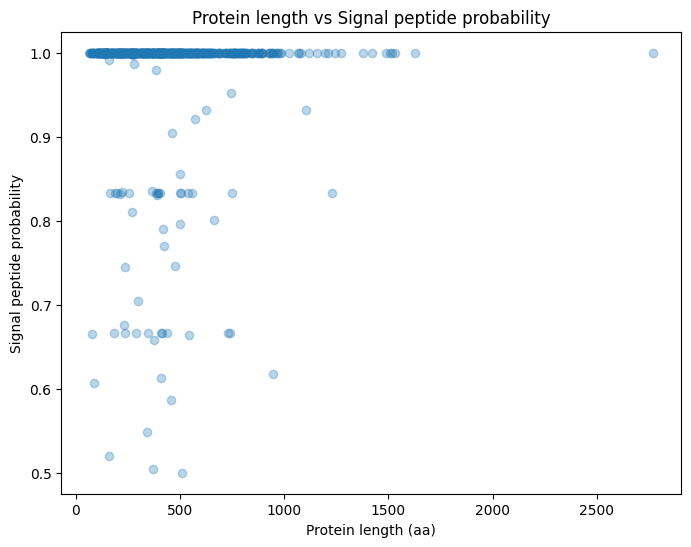

In [142]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(secreted["length"], secreted["SP(Sec/SPI)"], alpha=0.3)

plt.xlabel("Protein length (aa)")
plt.ylabel("Signal peptide probability")
plt.title("Protein length vs Signal peptide probability")

plt.show()

In [149]:
secreted["Prediction"]

0       SP
3       SP
6       SP
7       SP
9       SP
        ..
9069    SP
9074    SP
9083    SP
9085    SP
9089    SP
Name: Prediction, Length: 679, dtype: str

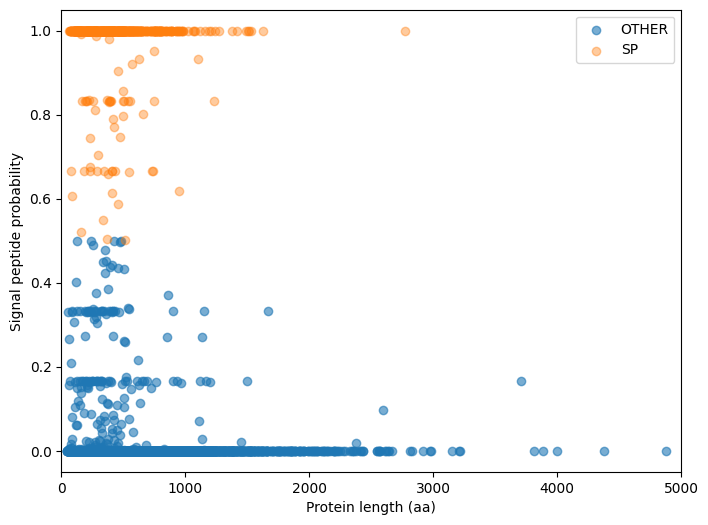

In [171]:
plt.figure(figsize=(8,6))

plt.scatter(df2[df2["Prediction"]=="OTHER"]["length"],
            df2[df2["Prediction"]=="OTHER"]["SP(Sec/SPI)"],
            alpha=0.6,
            label="OTHER")

plt.scatter(df2[df2["Prediction"]=="SP"]["length"],
            df2[df2["Prediction"]=="SP"]["SP(Sec/SPI)"],
            alpha=0.4,
            label="SP")

plt.xlabel("Protein length (aa)")
plt.ylabel("Signal peptide probability")
plt.legend()
plt.xlim(0,5000)
plt.savefig("N:\Jupiter_Projects\enzyme-genome-mining-course/results/sp_length_scatter.png")
plt.show()

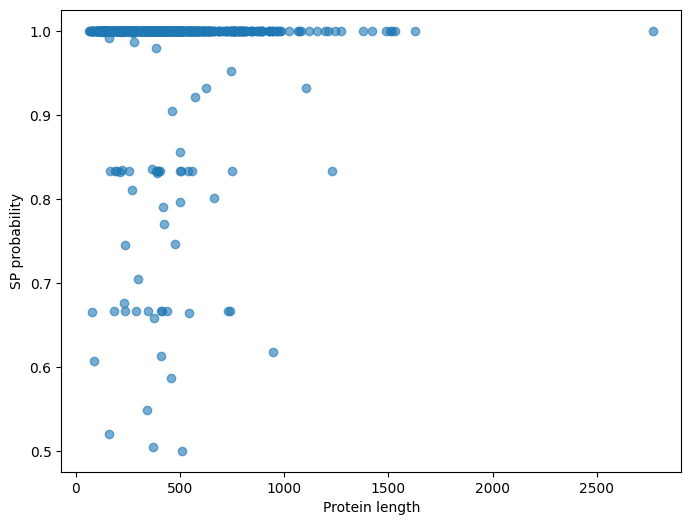

In [144]:
plt.figure(figsize=(8,6))
plt.scatter(secreted["length"], secreted["SP(Sec/SPI)"], alpha=0.6)
plt.xlabel("Protein length")
plt.ylabel("SP probability")
plt.show()

In [170]:
secreted.sort_values("length")

,# ID,Prediction,OTHER,SP(Sec/SPI),CS Position,protein_id,length
5296,tr|G0RH64|G0RH64_HYPJQ Predicted protein OS=Hy...,SP,0.000188,0.999796,CS pos: 17-18. Pr: 0.9749,G0RH64,65
4832,tr|G0RFA2|G0RFA2_HYPJQ Predicted protein OS=Hy...,SP,0.000181,0.999825,CS pos: 24-25. Pr: 0.6658,G0RFA2,67
5510,tr|G0RI26|G0RI26_HYPJQ Predicted protein OS=Hy...,SP,0.000189,0.999825,CS pos: 29-30. Pr: 0.6937,G0RI26,68
3975,tr|G0RBN0|G0RBN0_HYPJQ Predicted protein OS=Hy...,SP,0.000169,0.999800,CS pos: 18-19. Pr: 0.9780,G0RBN0,73
8494,tr|G0RVD1|G0RVD1_HYPJQ Predicted protein OS=Hy...,SP,0.000163,0.999845,CS pos: 19-20. Pr: 0.9822,G0RVD1,77
...,...,...,...,...,...,...,...
160,tr|G0RCD8|G0RCD8_HYPJQ Vacuolar protein sortin...,SP,0.000194,0.999804,CS pos: 27-28. Pr: 0.9787,G0RCD8,1508
7017,tr|G0RPB5|G0RPB5_HYPJQ Predicted protein OS=Hy...,SP,0.000176,0.999843,CS pos: 17-18. Pr: 0.9834,G0RPB5,1515
436,tr|G0RT37|G0RT37_HYPJQ chitinase OS=Hypocrea j...,SP,0.000159,0.999857,CS pos: 29-30. Pr: 0.5616,G0RT37,1531
4834,tr|G0RFA4|G0RFA4_HYPJQ Predicted protein OS=Hy...,SP,0.000171,0.999846,CS pos: 30-31. Pr: 0.4970,G0RFA4,1626
